In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
import src.data_cleaning as dc

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

BLUE, BLUE_LIGHT, ORANGE = "#2a78d6", "#9ec5f4", "#eb6834"
INK, INK_2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e3e2de"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.grid": True,
    "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10, "figure.dpi": 110,
})

raw = dc.load_raw()
print(f"Loaded {len(raw)} raw tables")
print(f"Revenue rule     : order_items.price, status in {dc.REVENUE_STATUSES}")
print(f"Customer key     : customer_unique_id")
print(f"Analysis window  : {dc.WINDOW_START.date()} .. {dc.WINDOW_END.date()}")

Loaded 9 raw tables
Revenue rule     : order_items.price, status in ('delivered',)
Customer key     : customer_unique_id
Analysis window  : 2017-01-01 .. 2018-08-31


In [2]:
orders_clean = dc.clean_orders(raw["orders"])

parsed = pd.DataFrame({
    "column": dc.ORDER_DATE_COLS,
    "raw_dtype": [str(raw["orders"][c].dtype) for c in dc.ORDER_DATE_COLS],
    "clean_dtype": [str(orders_clean[c].dtype) for c in dc.ORDER_DATE_COLS],
    "raw_nulls": [int(raw["orders"][c].isna().sum()) for c in dc.ORDER_DATE_COLS],
    "clean_nulls": [int(orders_clean[c].isna().sum()) for c in dc.ORDER_DATE_COLS],
})
parsed["new_nulls_from_parsing"] = parsed.clean_nulls - parsed.raw_nulls
display(parsed)

print("Zero new nulls => every non-empty timestamp string parsed cleanly.")
print(f"\norders_clean: {orders_clean.shape[0]:,} rows x {orders_clean.shape[1]} cols "
      f"(raw had {raw['orders'].shape[1]})")
print("\nDerived columns added:")
print(sorted(set(orders_clean.columns) - set(raw["orders"].columns)))

,column,raw_dtype,clean_dtype,raw_nulls,clean_nulls,new_nulls_from_parsing
0,order_purchase_timestamp,object,datetime64[ns],0,0,0
1,order_approved_at,object,datetime64[ns],160,160,0
2,order_delivered_carrier_date,object,datetime64[ns],1783,1783,0
3,order_delivered_customer_date,object,datetime64[ns],2965,2965,0
4,order_estimated_delivery_date,object,datetime64[ns],0,0,0


Zero new nulls => every non-empty timestamp string parsed cleanly.

orders_clean: 99,441 rows x 25 cols (raw had 8)

Derived columns added:
['approval_days', 'carrier_days', 'delivery_days', 'delivery_vs_estimate_days', 'estimated_days', 'in_window', 'is_delivered', 'is_late', 'order_date', 'order_dow', 'order_hour', 'order_month', 'order_quarter', 'order_year', 'shipping_days', 'status_date_conflict', 'timeline_valid']


In [3]:
o_raw = raw["orders"].copy()
for c in dc.ORDER_DATE_COLS:
    o_raw[c] = pd.to_datetime(o_raw[c], errors="coerce")

day = 86_400
before = pd.DataFrame({
    "approval_days":  (o_raw.order_approved_at - o_raw.order_purchase_timestamp).dt.total_seconds() / day,
    "carrier_days":   (o_raw.order_delivered_carrier_date - o_raw.order_approved_at).dt.total_seconds() / day,
    "shipping_days":  (o_raw.order_delivered_customer_date - o_raw.order_delivered_carrier_date).dt.total_seconds() / day,
    "delivery_days":  (o_raw.order_delivered_customer_date - o_raw.order_purchase_timestamp).dt.total_seconds() / day,
})

comp = pd.DataFrame({
    "negatives_before": (before < 0).sum(),
    "min_before": before.min().round(2),
    "mean_before": before.mean().round(2),
    "negatives_after": (orders_clean[before.columns] < 0).sum(),
    "min_after": orders_clean[before.columns].min().round(2),
    "mean_after": orders_clean[before.columns].mean().round(2),
})
display(comp)

print(f"orders flagged timeline_valid = False : {int((~orders_clean.timeline_valid).sum()):,}")
print(f"orders flagged status_date_conflict   : {int(orders_clean.status_date_conflict.sum()):,}")
print("\nWorst single violation (carrier pickup 171 days before approval):")
worst = orders_clean.loc[[before.carrier_days.idxmin()]]
display(worst[["order_id", "order_status", "order_approved_at",
               "order_delivered_carrier_date", "carrier_days", "timeline_valid"]])

,negatives_before,min_before,mean_before,negatives_after,min_after,mean_after
approval_days,0,0.00,0.43,0,0.00,0.43
carrier_days,1359,-171.22,2.81,0,0.00,2.86
shipping_days,23,-16.10,9.33,0,0.00,9.33
delivery_days,0,0.53,12.56,0,0.53,12.56


orders flagged timeline_valid = False : 1,382
orders flagged status_date_conflict   : 14

Worst single violation (carrier pickup 171 days before approval):


,order_id,order_status,order_approved_at,order_delivered_carrier_date,carrier_days,timeline_valid
25883,7c48bb55e8e4f7e56d412e9653db37bc,delivered,2018-07-16 18:50:22,2018-01-26 13:35:00,NaN,False


In [4]:
items_clean = dc.clean_order_items(raw["order_items"])
payments_clean = dc.clean_payments(raw["payments"])

print("PRICE / FREIGHT VALIDITY (order_items)")
print(f"  price <= 0                 : {int((items_clean.price <= 0).sum())}")
print(f"  freight < 0                : {int((items_clean.freight_value < 0).sum())}")
print(f"  freight == 0 (free ship)   : {int(items_clean.free_freight.sum())}  -> kept, real offers")
print(f"  invalid shipping_limit_date: {int(items_clean.invalid_shipping_limit.sum())}  -> flagged")
display(items_clean[items_clean.invalid_shipping_limit][
    ["order_id", "shipping_limit_date", "price", "invalid_shipping_limit"]])

print("\nPAYMENT ANOMALIES — three distinct problems, three treatments")
anomalies = raw["payments"].copy()
totals = anomalies.groupby("order_id").payment_value.transform("sum")

zero_voucher = anomalies[(anomalies.payment_value == 0) & (anomalies.payment_type == "voucher")]
print(f"\n  (a) zero-value voucher rows : {len(zero_voucher)}")
print("      their orders' total payment value:")
display(zero_voucher.assign(order_total=totals[zero_voucher.index])[
    ["order_id", "payment_sequential", "payment_type", "payment_value", "order_total"]])

PRICE / FREIGHT VALIDITY (order_items)
  price <= 0                 : 0
  freight < 0                : 0
  freight == 0 (free ship)   : 383  -> kept, real offers
  invalid shipping_limit_date: 4  -> flagged


,order_id,shipping_limit_date,price,invalid_shipping_limit
8643,13bdf405f961a6deec817d817f5c6624,2020-02-05 03:30:51,69.99,True
68516,9c94a4ea2f7876660fa6f1b59b69c8e6,2020-02-03 20:23:22,75.99,True
85729,c2bb89b5c1dd978d507284be78a04cb2,2020-04-09 22:35:08,99.99,True
85730,c2bb89b5c1dd978d507284be78a04cb2,2020-04-09 22:35:08,99.99,True



PAYMENT ANOMALIES — three distinct problems, three treatments

  (a) zero-value voucher rows : 6
      their orders' total payment value:


,order_id,payment_sequential,payment_type,payment_value,order_total
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,0.00,74.16
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,0.00,457.99
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,0.00,122.04
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,0.00,71.14
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,0.00,457.99
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,0.00,171.57


In [5]:
undefined = anomalies[anomalies.payment_type == "not_defined"]
print(f"  (b) payment_type='not_defined' rows : {len(undefined)}")
print("      these are the ONLY payment row for their order, and total R$0.00:")
display(undefined.assign(order_total=totals[undefined.index],
                         rows_for_order=undefined.order_id.map(anomalies.order_id.value_counts()))[
    ["order_id", "payment_type", "payment_value", "rows_for_order", "order_total"]])

zero_inst = anomalies[anomalies.payment_installments == 0]
print(f"\n  (c) zero-instalment rows : {len(zero_inst)}  -> imputed to 1")
display(zero_inst[["order_id", "payment_type", "payment_installments", "payment_value"]])
print("After cleaning:")
display(payments_clean.loc[payments_clean.installments_imputed,
        ["order_id", "payment_type", "payment_installments", "installments_imputed"]])

print(f"\nrows flagged is_valid_payment = False : {int((~payments_clean.is_valid_payment).sum())}")
print(f"orders with no recoverable payment value: "
      f"{payments_clean.loc[payments_clean.order_has_no_payment_value, 'order_id'].nunique()}")

  (b) payment_type='not_defined' rows : 3
      these are the ONLY payment row for their order, and total R$0.00:


,order_id,payment_type,payment_value,rows_for_order,order_total
51280,4637ca194b6387e2d538dc89b124b0ee,not_defined,0.00,1,0.00
57411,00b1cb0320190ca0daa2c88b35206009,not_defined,0.00,1,0.00
94427,c8c528189310eaa44a745b8d9d26908b,not_defined,0.00,1,0.00



  (c) zero-instalment rows : 2  -> imputed to 1


,order_id,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,credit_card,0,129.94


After cleaning:


,order_id,payment_type,payment_installments,installments_imputed
46982,744bade1fcf9ff3f31d860ace076d422,credit_card,1,True
79014,1a57108394169c0b47d8f876acc9ba2d,credit_card,1,True



rows flagged is_valid_payment = False : 9
orders with no recoverable payment value: 3


In [6]:
price = items_clean.price
q1, q3 = price.quantile(.25), price.quantile(.75)
fence = q3 + 1.5 * (q3 - q1)
above = price > fence

print("IF WE APPLIED THE TEXTBOOK IQR RULE TO price")
print(f"  Q1 = R$ {q1:,.2f}   Q3 = R$ {q3:,.2f}   upper fence = R$ {fence:,.2f}")
print(f"  rows flagged as 'outliers' : {int(above.sum()):,}  ({above.mean()*100:.2f}% of rows)")
print(f"  revenue in those rows      : R$ {price[above].sum():,.2f}")
print(f"  share of ALL revenue       : {price[above].sum() / price.sum() * 100:.2f}%   <-- would be deleted")
print(f"  distinct products involved : {items_clean.loc[above, 'product_id'].nunique():,}")

print("\nDO THE 'OUTLIER' PRODUCTS RECUR? (a one-off typo would not)")
recur = items_clean.loc[above, "product_id"].value_counts()
print(f"  most-sold high-price product appears {recur.iloc[0]} times")
print(f"  products above the fence sold more than 10 times: {int((recur > 10).sum()):,}")
display(recur.head(5).rename("times_sold").to_frame())

IF WE APPLIED THE TEXTBOOK IQR RULE TO price
  Q1 = R$ 39.90   Q3 = R$ 134.90   upper fence = R$ 277.40
  rows flagged as 'outliers' : 8,427  (7.48% of rows)
  revenue in those rows      : R$ 4,839,551.84
  share of ALL revenue       : 35.61%   <-- would be deleted
  distinct products involved : 3,715

DO THE 'OUTLIER' PRODUCTS RECUR? (a one-off typo would not)
  most-sold high-price product appears 195 times
  products above the fence sold more than 10 times: 88


,times_sold
product_id,
bb50f2e236e5eea0100680137654686c,195
6cdd53843498f92890544667809f1595,156
5f504b3a1c75b73d6151be81eb05bdc9,63
d285360f29ac7fd97640bf0baef03de0,56
f819f0c84a64f02d3a5606ca95edd272,45


In [7]:
top = (items_clean.nlargest(8, "price")
       .merge(dc.clean_products(raw["products"], raw["category_translation"])[
           ["product_id", "product_category_name_english"]], on="product_id", how="left"))
print("THE MOST EXPENSIVE ITEMS — are these plausible products?")
display(top[["price", "freight_value", "product_category_name_english"]])

print("\nOTHER EXTREMES, CHECKED INDIVIDUALLY")
prod_tmp = dc.clean_products(raw["products"], raw["category_translation"])
pay_max = raw["payments"].nlargest(1, "payment_value").iloc[0]
big_items = items_clean[items_clean.order_id == pay_max.order_id]
basket = items_clean.groupby("order_id").size()
big_basket = basket.idxmax()

print(f"  largest payment R$ {pay_max.payment_value:,.2f} -> that order has {len(big_items)} items "
      f"totalling R$ {big_items.item_total.sum():,.2f}  (reconciles exactly)")
print(f"  heaviest product {prod_tmp.product_weight_g.max():,.0f} g -> category "
      f"'{prod_tmp.loc[prod_tmp.product_weight_g.idxmax(), 'product_category_name_english']}'")
print(f"  largest basket {basket.max()} units -> {items_clean.loc[items_clean.order_id == big_basket, 'product_id'].nunique()} "
      f"distinct products at R$ {items_clean.loc[items_clean.order_id == big_basket, 'price'].iloc[0]:.2f} each (bulk buy)")
print(f"  highest freight R$ {items_clean.freight_value.max():,.2f} -> on a "
      f"{prod_tmp.set_index('product_id').loc[items_clean.loc[items_clean.freight_value.idxmax(), 'product_id'], 'product_weight_g']:,.0f} g product")

THE MOST EXPENSIVE ITEMS — are these plausible products?


,price,freight_value,product_category_name_english
0,"6,735.00",194.31,housewares
1,"6,729.00",193.21,computers
2,"6,499.00",227.66,art
3,"4,799.00",151.34,small_appliances
4,"4,690.00",74.34,small_appliances
5,"4,590.00",91.78,computers
6,"4,399.87",113.45,musical_instruments
7,"4,099.99",75.27,consoles_games



OTHER EXTREMES, CHECKED INDIVIDUALLY
  largest payment R$ 13,664.08 -> that order has 8 items totalling R$ 13,664.08  (reconciles exactly)
  heaviest product 40,425 g -> category 'bed_bath_table'
  largest basket 21 units -> 3 distinct products at R$ 1.20 each (bulk buy)
  highest freight R$ 409.68 -> on a 14,675 g product


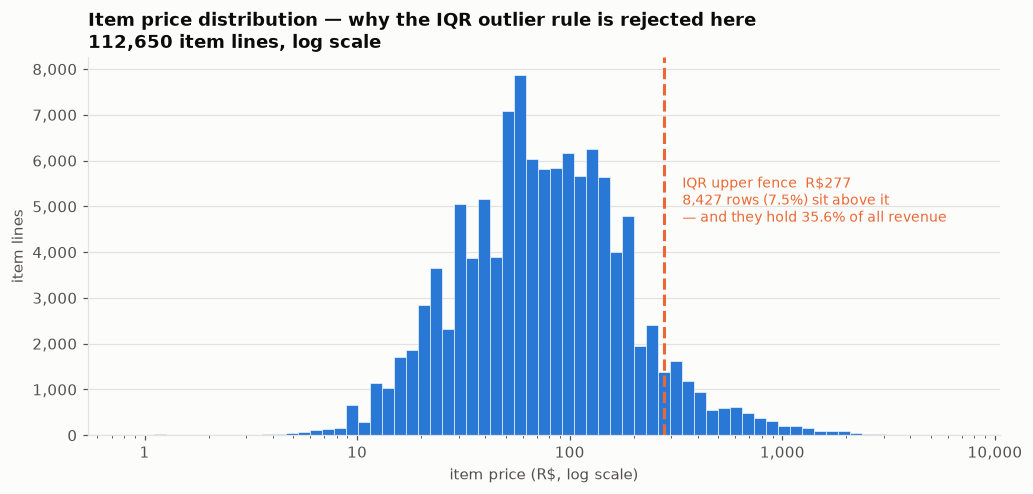

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

bins = np.logspace(np.log10(price.min()), np.log10(price.max()), 70)
ax.hist(price, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
ax.set_xscale("log")

ax.axvline(fence, color=ORANGE, linewidth=2, linestyle="--")
ax.annotate(f"IQR upper fence  R${fence:,.0f}\n"
            f"{above.sum():,} rows ({above.mean()*100:.1f}%) sit above it\n"
            f"— and they hold {price[above].sum()/price.sum()*100:.1f}% of all revenue",
            xy=(fence, ax.get_ylim()[1] * 0.62), xytext=(12, 0), textcoords="offset points",
            fontsize=9, color=ORANGE, va="center")

ax.set_title("Item price distribution — why the IQR outlier rule is rejected here\n"
             "112,650 item lines, log scale")
ax.set_xlabel("item price (R$, log scale)")
ax.set_ylabel("item lines")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
dd = orders_clean.delivery_days
print("DELIVERY TIME (delivered orders)")
print(dd.describe(percentiles=[.5, .9, .95, .99]).to_string())
print(f"\n  > 60 days : {int((dd > 60).sum()):,}")
print(f"  > 100 days: {int((dd > 100).sum()):,}")

slow = orders_clean[orders_clean.delivery_days > 100]
print(f"\nWHEN were the 64 slowest orders delivered?")
display(slow.order_delivered_customer_date.dt.date.value_counts().head(4).rename("orders").to_frame())

one_day = orders_clean[orders_clean.order_delivered_customer_date.dt.date.astype(str) == "2017-09-19"]
daily = orders_clean.order_delivered_customer_date.dt.date.value_counts()
sept_2017 = orders_clean[(orders_clean.order_month == "2017-09")]
print(f"\nTHE 2017-09-19 CLUSTER")
print(f"  orders delivered that day        : {len(one_day):,}")
print(f"  typical deliveries/day in Sep 2017: ~{int(daily[daily.index.astype(str).str.startswith('2017-09')].median())}")
print(f"  purchase dates involved          : {one_day.order_purchase_timestamp.min().date()} .. "
      f"{one_day.order_purchase_timestamp.max().date()}")
print(f"  delivery_days range              : {one_day.delivery_days.min():.1f} .. {one_day.delivery_days.max():.1f}")
print(f"  of the 64 slowest orders overall, {int((slow.order_delivered_customer_date.dt.date.astype(str) == '2017-09-19').sum())} were delivered on this one day")
print(f"  timestamps spread across the day : {one_day.order_delivered_customer_date.min().time()} .. "
      f"{one_day.order_delivered_customer_date.max().time()}")

DELIVERY TIME (delivered orders)
count   96,476.00
mean        12.56
std          9.55
min          0.53
50%         10.22
90%         23.10
95%         29.28
99%         46.05
max        209.63

  > 60 days : 306
  > 100 days: 64

WHEN were the 64 slowest orders delivered?


,orders
order_delivered_customer_date,
2017-09-19,21
2018-04-19,2
2018-05-07,1
2018-02-05,1



THE 2017-09-19 CLUSTER
  orders delivered that day        : 282
  typical deliveries/day in Sep 2017: ~162
  purchase dates involved          : 2017-02-21 .. 2017-09-18
  delivery_days range              : 1.1 .. 209.6
  of the 64 slowest orders overall, 21 were delivered on this one day
  timestamps spread across the day : 00:06:59 .. 23:44:58


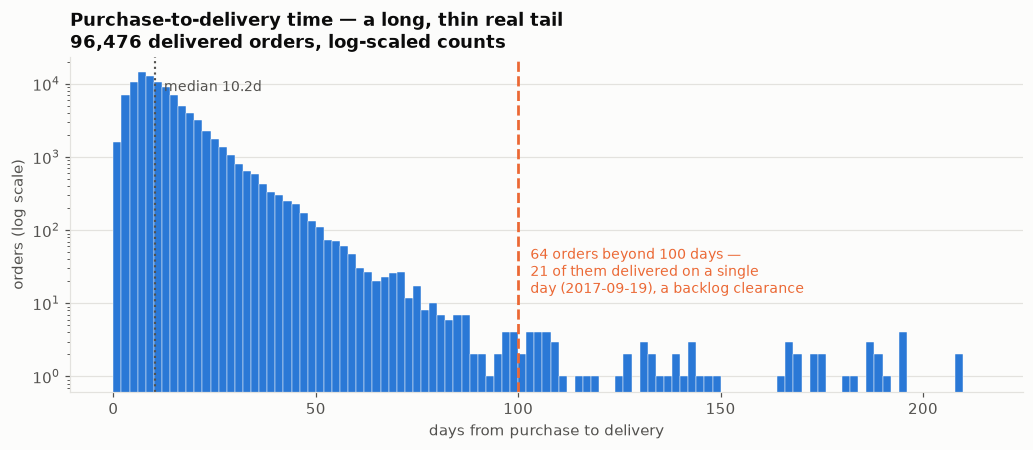

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

ax.hist(dd.dropna(), bins=np.arange(0, 215, 2), color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.set_yscale("log")

ax.axvline(dd.median(), color=INK_2, linewidth=1.4, linestyle=":")
ax.annotate(f"median {dd.median():.1f}d", xy=(dd.median(), 8000), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=INK_2)
ax.axvline(100, color=ORANGE, linewidth=1.8, linestyle="--")
ax.annotate("64 orders beyond 100 days —\n21 of them delivered on a single\nday (2017-09-19), a backlog clearance",
            xy=(103, 60), fontsize=9, color=ORANGE, va="top")

ax.set_title("Purchase-to-delivery time — a long, thin real tail\n"
             "96,476 delivered orders, log-scaled counts")
ax.set_xlabel("days from purchase to delivery")
ax.set_ylabel("orders (log scale)")
ax.grid(axis="x", visible=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
products_clean = dc.clean_products(raw["products"], raw["category_translation"])
reviews_clean = dc.clean_reviews(raw["reviews"])
customers_clean = dc.clean_customers(raw["customers"])
sellers_clean = dc.clean_sellers(raw["sellers"])

treatment = pd.DataFrame([
    ("orders", "order_delivered_customer_date", 2965, "left as NaT; delivery KPIs computed on delivered subset only",
     "Null because the order was never delivered — imputing a date would invent a delivery"),
    ("orders", "order_delivered_carrier_date", 1783, "left as NaT",
     "Same: order never reached a carrier"),
    ("orders", "order_approved_at", 160, "left as NaT",
     "Payment never approved; 14 of these are still marked delivered (flagged)"),
    ("products", "product_category_name", 610, "filled with 'unknown' (explicit bucket)",
     "Carries R$179,535 of real revenue — dropping would understate every category total"),
    ("products", "product_name_length / description_length / photos_qty", 610, "left as NaN",
     "Listing metadata, not used for revenue; same 610 uncategorised products"),
    ("products", "product_weight_g / dimensions", 2, "left as NaN",
     "Only affects freight analysis; no basis for imputing a physical size"),
    ("reviews", "review_comment_title", 87656, "left as NaN; boolean has_comment added",
     "Optional free-text field — null means 'no comment written', not missing data"),
    ("reviews", "review_comment_message", 58247, "left as NaN; boolean has_comment added",
     "Same — absence is itself the signal"),
], columns=["table", "column", "missing", "treatment", "reason"])

with pd.option_context("display.max_colwidth", 85):
    display(treatment)

print("Nothing is mean/median-imputed anywhere in this pipeline.")
print("Every null above is either structurally meaningful or explicitly bucketed.")

,table,column,missing,treatment,reason
0,orders,order_delivered_customer_date,2965,left as NaT; delivery KPIs computed on delivered subset only,Null because the order was never delivered — imputing a date would invent a delivery
1,orders,order_delivered_carrier_date,1783,left as NaT,Same: order never reached a carrier
2,orders,order_approved_at,160,left as NaT,Payment never approved; 14 of these are still marked delivered (flagged)
3,products,product_category_name,610,filled with 'unknown' (explicit bucket),"Carries R$179,535 of real revenue — dropping would understate every category total"
4,products,product_name_length / description_length / photos_qty,610,left as NaN,"Listing metadata, not used for revenue; same 610 uncategorised products"
5,products,product_weight_g / dimensions,2,left as NaN,Only affects freight analysis; no basis for imputing a physical size
6,reviews,review_comment_title,87656,left as NaN; boolean has_comment added,"Optional free-text field — null means 'no comment written', not missing data"
7,reviews,review_comment_message,58247,left as NaN; boolean has_comment added,Same — absence is itself the signal


Nothing is mean/median-imputed anywhere in this pipeline.
Every null above is either structurally meaningful or explicitly bucketed.


In [12]:
print("BEFORE")
print(f"  distinct categories in products        : {raw['products'].product_category_name.nunique()}")
print(f"  rows in the translation table          : {len(raw['category_translation'])}")
untranslated = sorted(set(raw["products"].product_category_name.dropna())
                      - set(raw["category_translation"].product_category_name))
print(f"  categories with NO English translation : {untranslated}")
print(f"  products with no category              : {int(raw['products'].product_category_name.isna().sum())}")

exposure = []
for cat in untranslated:
    pids = raw["products"].loc[raw["products"].product_category_name == cat, "product_id"]
    sub = items_clean[items_clean.product_id.isin(pids)]
    exposure.append((cat, len(pids), len(sub), sub.price.sum()))
null_pids = raw["products"].loc[raw["products"].product_category_name.isna(), "product_id"]
null_sub = items_clean[items_clean.product_id.isin(null_pids)]
exposure.append(("(no category)", len(null_pids), len(null_sub), null_sub.price.sum()))
display(pd.DataFrame(exposure, columns=["category", "products", "item_lines", "gross_revenue"]))

print("\nAFTER")
print(f"  distinct categories PT : {products_clean.product_category_name.nunique()}  (73 + 'unknown')")
print(f"  distinct categories EN : {products_clean.product_category_name_english.nunique()}")
print(f"  English nulls remaining: {int(products_clean.product_category_name_english.isna().sum())}")
display(products_clean.loc[
    products_clean.product_category_name.isin(untranslated),
    ["product_category_name", "product_category_name_english"]].drop_duplicates())

BEFORE
  distinct categories in products        : 73
  rows in the translation table          : 71
  categories with NO English translation : ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
  products with no category              : 610


,category,products,item_lines,gross_revenue
0,pc_gamer,3,9,"1,545.95"
1,portateis_cozinha_e_preparadores_de_alimentos,10,15,"3,968.53"
2,(no category),610,1603,"179,535.28"



AFTER
  distinct categories PT : 74  (73 + 'unknown')
  distinct categories EN : 74
  English nulls remaining: 0


,product_category_name,product_category_name_english
1628,pc_gamer,pc_gamer
5821,portateis_cozinha_e_preparadores_de_alimentos,kitchen_portables_and_food_preparers


In [13]:
print("REVIEWS — deduplicate to one row per order")
print(f"  before : {len(raw['reviews']):,} rows, {raw['reviews'].order_id.nunique():,} distinct orders")
print(f"  after  : {len(reviews_clean):,} rows, {reviews_clean.order_id.nunique():,} distinct orders")
print(f"  removed: {len(raw['reviews']) - len(reviews_clean):,} rows")
print(f"  orders that had >1 review : {int(reviews_clean.had_multiple_reviews.sum()):,}")

conflict = (raw["reviews"][raw["reviews"].order_id.duplicated(keep=False)]
            .groupby("order_id").review_score.agg(["min", "max", "nunique"]))
conflicting = conflict[conflict["nunique"] > 1]
print(f"  of those, with CONFLICTING scores : {len(conflicting):,} "
      f"(mean spread {(conflicting['max'] - conflicting['min']).mean():.2f} stars)")

shift = pd.DataFrame({
    "before_pct": (raw["reviews"].review_score.value_counts(normalize=True).sort_index() * 100).round(2),
    "after_pct": (reviews_clean.review_score.value_counts(normalize=True).sort_index() * 100).round(2),
})
shift["shift_pp"] = (shift.after_pct - shift.before_pct).round(3)
print(f"\n  mean score before {raw['reviews'].review_score.mean():.4f} -> after {reviews_clean.review_score.mean():.4f}")
display(shift)

REVIEWS — deduplicate to one row per order
  before : 99,224 rows, 98,673 distinct orders
  after  : 98,673 rows, 98,673 distinct orders
  removed: 551 rows
  orders that had >1 review : 547
  of those, with CONFLICTING scores : 202 (mean spread 2.04 stars)

  mean score before 4.0864 -> after 4.0864


,before_pct,after_pct,shift_pp
review_score,,,
1,11.51,11.52,0.01
2,3.18,3.17,-0.01
3,8.24,8.24,0.00
4,19.29,19.29,0.00
5,57.78,57.77,-0.01


In [14]:
geolocation_clean = dc.clean_geolocation(raw["geolocation"])

print("GEOLOCATION — collapse to one row per zip prefix")
print(f"  before            : {len(raw['geolocation']):,} rows "
      f"({int(raw['geolocation'].duplicated().sum()):,} exact duplicates, "
      f"{raw['geolocation'].geolocation_zip_code_prefix.nunique():,} zip prefixes)")
in_br = (raw["geolocation"].geolocation_lat.between(dc.BR_LAT_MIN, dc.BR_LAT_MAX)
         & raw["geolocation"].geolocation_lng.between(dc.BR_LNG_MIN, dc.BR_LNG_MAX))
print(f"  corrupt coords removed : {int((~in_br).sum())} rows outside Brazil's bounding box")
print(f"  after             : {len(geolocation_clean):,} rows (one per zip prefix, median lat/lng)")
print(f"  reduction         : {(1 - len(geolocation_clean)/len(raw['geolocation']))*100:.1f}%")
print(f"\n  customer zips with no coordinates : "
      f"{int((~customers_clean.customer_zip_code_prefix.isin(geolocation_clean.geolocation_zip_code_prefix)).sum())}")
print(f"  seller zips with no coordinates   : "
      f"{int((~sellers_clean.seller_zip_code_prefix.isin(geolocation_clean.geolocation_zip_code_prefix)).sum())}")
display(geolocation_clean.head(3))

GEOLOCATION — collapse to one row per zip prefix


  before            : 1,000,163 rows (261,831 exact duplicates, 19,015 zip prefixes)
  corrupt coords removed : 42 rows outside Brazil's bounding box
  after             : 19,010 rows (one per zip prefix, median lat/lng)
  reduction         : 98.1%

  customer zips with no coordinates : 279
  seller zips with no coordinates   : 7


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,n_observations
0,1001,-23.55,-46.63,sao paulo,SP,26
1,1002,-23.55,-46.64,sao paulo,SP,13
2,1003,-23.55,-46.64,sao paulo,SP,17


In [15]:
fk = pd.DataFrame([
    ("order_items.order_id -> orders", int((~items_clean.order_id.isin(orders_clean.order_id)).sum())),
    ("order_items.product_id -> products", int((~items_clean.product_id.isin(products_clean.product_id)).sum())),
    ("order_items.seller_id -> sellers", int((~items_clean.seller_id.isin(sellers_clean.seller_id)).sum())),
    ("orders.customer_id -> customers", int((~orders_clean.customer_id.isin(customers_clean.customer_id)).sum())),
    ("payments.order_id -> orders", int((~payments_clean.order_id.isin(orders_clean.order_id)).sum())),
    ("reviews.order_id -> orders", int((~reviews_clean.order_id.isin(orders_clean.order_id)).sum())),
    ("products.category -> translation", int(products_clean.product_category_name_english.isna().sum())),
], columns=["foreign_key", "orphans_after_cleaning"])
display(fk)

no_items = orders_clean[~orders_clean.order_id.isin(items_clean.order_id)]
print(f"CHILDLESS PARENTS — orders with no item lines: {len(no_items):,}")
display(no_items.order_status.value_counts().rename("orders").to_frame()
        .query("orders > 0"))
print("Treatment: kept with order_revenue = 0 and n_items = 0 (see fct_orders), NOT dropped,")
print("so that cancellation and stock-out analysis remains possible in later phases.")

,foreign_key,orphans_after_cleaning
0,order_items.order_id -> orders,0
1,order_items.product_id -> products,0
2,order_items.seller_id -> sellers,0
3,orders.customer_id -> customers,0
4,payments.order_id -> orders,0
5,reviews.order_id -> orders,0
6,products.category -> translation,0


CHILDLESS PARENTS — orders with no item lines: 775


,orders
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


Treatment: kept with order_revenue = 0 and n_items = 0 (see fct_orders), NOT dropped,
so that cancellation and stock-out analysis remains possible in later phases.


In [16]:
fct_order_items = dc.build_order_items_fact(
    orders_clean, items_clean, customers_clean, products_clean, sellers_clean)
fct_orders = dc.build_orders_fact(
    orders_clean, items_clean, customers_clean, payments_clean, reviews_clean)

print(f"fct_order_items : {fct_order_items.shape[0]:,} rows x {fct_order_items.shape[1]} cols  (one row per product line)")
print(f"fct_orders      : {fct_orders.shape[0]:,} rows x {fct_orders.shape[1]} cols  (one row per order)")
print("\nfct_orders columns:")
print(sorted(fct_orders.columns.tolist()))
display(fct_orders[["order_id", "customer_unique_id", "order_month", "order_status",
                    "order_revenue", "order_freight", "n_items", "payment_type",
                    "review_score", "customer_state", "is_delivered", "in_window"]].head())

fct_order_items : 112,650 rows x 34 cols  (one row per product line)
fct_orders      : 99,441 rows x 45 cols  (one row per order)

fct_orders columns:
['approval_days', 'avg_item_price', 'carrier_days', 'customer_city', 'customer_id', 'customer_state', 'customer_unique_id', 'customer_zip_code_prefix', 'delivery_days', 'delivery_vs_estimate_days', 'estimated_days', 'has_comment', 'has_items', 'in_window', 'is_delivered', 'is_late', 'is_multi_item', 'max_installments', 'max_item_price', 'n_distinct_products', 'n_items', 'n_payment_records', 'n_sellers', 'order_approved_at', 'order_date', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_dow', 'order_estimated_delivery_date', 'order_freight', 'order_hour', 'order_id', 'order_month', 'order_purchase_timestamp', 'order_quarter', 'order_revenue', 'order_status', 'order_year', 'payment_total', 'payment_type', 'response_days', 'review_score', 'shipping_days', 'status_date_conflict', 'timeline_valid']


,order_id,customer_unique_id,order_month,order_status,order_revenue,order_freight,n_items,payment_type,review_score,customer_state,is_delivered,in_window
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10,delivered,29.99,8.72,1.00,voucher,4.00,SP,True,True
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07,delivered,118.70,22.76,1.00,boleto,4.00,BA,True,True
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,delivered,159.90,19.22,1.00,credit_card,5.00,GO,True,True
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11,delivered,45.00,27.20,1.00,credit_card,5.00,RN,True,True
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,delivered,19.90,8.72,1.00,credit_card,5.00,SP,True,True


In [17]:
checks = []
def check(name, condition, detail=""):
    checks.append({"check": name, "result": "PASS" if condition else "FAIL", "detail": detail})

raw_revenue = raw["order_items"].price.sum()
check("No row inflation in item fact table",
      len(fct_order_items) == len(raw["order_items"]),
      f"{len(fct_order_items):,} == {len(raw['order_items']):,}")
check("No row inflation in order fact table",
      len(fct_orders) == len(raw["orders"]),
      f"{len(fct_orders):,} == {len(raw['orders']):,}")
check("order_id is unique in fct_orders", fct_orders.order_id.is_unique)
check("Revenue preserved exactly (item grain)",
      round(fct_order_items.revenue.sum(), 2) == round(raw_revenue, 2),
      f"R$ {fct_order_items.revenue.sum():,.2f}")
check("Revenue preserved exactly (order grain)",
      round(fct_orders.order_revenue.sum(), 2) == round(raw_revenue, 2),
      f"R$ {fct_orders.order_revenue.sum():,.2f}")
check("Every order has a customer_unique_id",
      fct_orders.customer_unique_id.isna().sum() == 0)
check("Every item line has an English category",
      fct_order_items.product_category_name_english.isna().sum() == 0)
check("One review per order", reviews_clean.order_id.is_unique)
check("One geolocation row per zip prefix",
      geolocation_clean.geolocation_zip_code_prefix.is_unique)
check("No negative stage durations remain",
      (orders_clean[["approval_days", "carrier_days", "shipping_days", "delivery_days"]].min() >= 0).all())
check("No negative or zero prices", (items_clean.price > 0).all())
check("Customer count unchanged",
      customers_clean.customer_unique_id.nunique() == raw["customers"].customer_unique_id.nunique(),
      f"{customers_clean.customer_unique_id.nunique():,} people")

results = pd.DataFrame(checks)
display(results)
print(f"{(results.result == 'PASS').sum()} / {len(results)} checks passed")
assert (results.result == "PASS").all(), "Cleaning validation failed"

,check,result,detail
0,No row inflation in item fact table,PASS,"112,650 == 112,650"
1,No row inflation in order fact table,PASS,"99,441 == 99,441"
2,order_id is unique in fct_orders,PASS,
3,Revenue preserved exactly (item grain),PASS,"R$ 13,591,643.70"
4,Revenue preserved exactly (order grain),PASS,"R$ 13,591,643.70"
5,Every order has a customer_unique_id,PASS,
6,Every item line has an English category,PASS,
7,One review per order,PASS,
8,One geolocation row per zip prefix,PASS,
9,No negative stage durations remain,PASS,


12 / 12 checks passed


In [18]:
print("HEADLINE FIGURES AFTER CLEANING")
gross = fct_orders.order_revenue.sum()
delivered = fct_orders.loc[fct_orders.is_delivered, "order_revenue"].sum()
analytic = fct_orders.loc[fct_orders.is_delivered & fct_orders.in_window]

print(f"  gross revenue (all statuses)          : R$ {gross:,.2f}")
print(f"  delivered revenue                     : R$ {delivered:,.2f}  ({delivered/gross*100:.2f}%)")
print(f"  delivered + in analysis window        : R$ {analytic.order_revenue.sum():,.2f}")
print(f"  orders in the analysis base           : {len(analytic):,}")
print(f"  customers (people) in analysis base   : {analytic.customer_unique_id.nunique():,}")
print(f"  freight (tracked separately)          : R$ {fct_orders.order_freight.sum():,.2f}")

excluded = fct_orders[~fct_orders.in_window]
print(f"\n  orders excluded by the time window     : {len(excluded):,}")
print(f"  revenue excluded (delivered only)     : R$ "
      f"{fct_orders.loc[~fct_orders.in_window & fct_orders.is_delivered, 'order_revenue'].sum():,.2f} "
      f"({fct_orders.loc[~fct_orders.in_window & fct_orders.is_delivered, 'order_revenue'].sum()/delivered*100:.2f}% of delivered)")
display(excluded.order_month.value_counts().sort_index().rename("orders_excluded").to_frame())

HEADLINE FIGURES AFTER CLEANING
  gross revenue (all statuses)          : R$ 13,591,643.70
  delivered revenue                     : R$ 13,221,498.11  (97.28%)
  delivered + in analysis window        : R$ 13,181,027.13
  orders in the analysis base           : 96,211
  customers (people) in analysis base   : 93,104
  freight (tracked separately)          : R$ 2,251,909.54

  orders excluded by the time window     : 349
  revenue excluded (delivered only)     : R$ 40,470.98 (0.31% of delivered)


,orders_excluded
order_month,
2016-09,4
2016-10,324
2016-12,1
2018-09,16
2018-10,4


In [19]:
n = lambda x: int(x)
report = pd.DataFrame([
    ("Duplicates", "reviews",
     f"{n(len(raw['reviews']) - len(reviews_clean))} rows: review_id not unique; {n(reviews_clean.had_multiple_reviews.sum())} orders had >1 review ({len(conflicting)} conflicting)",
     "Deduplicated to most recent review per order (answer timestamp)",
     "Prevents join fan-out inflating order revenue. Measured impact on mean score: 0.0000"),
    ("Duplicates", "geolocation",
     f"{n(raw['geolocation'].duplicated().sum()):,} exact duplicate rows; {len(raw['geolocation']):,} rows for {raw['geolocation'].geolocation_zip_code_prefix.nunique():,} zips",
     f"Collapsed to {len(geolocation_clean):,} rows (one per zip, median lat/lng)",
     "A raw join would multiply the customer base ~50x"),
    ("Invalid dates", "orders",
     f"{n((~orders_clean.timeline_valid).sum()):,} orders with negative stage durations (worst -171 days)",
     "Raw timestamps kept; derived durations set to NaN; timeline_valid flag",
     "Negative durations are impossible and would drag every delivery KPI down"),
    ("Invalid dates", "orders",
     f"{n(orders_clean.status_date_conflict.sum())} orders where status and timestamps disagree",
     "Flagged status_date_conflict; kept",
     "Cannot know which field is wrong; excluding them from delivery KPIs is enough"),
    ("Invalid dates", "order_items",
     f"{n(items_clean.invalid_shipping_limit.sum())} rows with shipping_limit_date up to 2020",
     "Flagged invalid_shipping_limit; kept",
     "Clearly erroneous, but the row's price and product are still valid"),
    ("Time window", "orders",
     f"{n((~orders_clean.in_window).sum())} orders outside Jan-2017..Aug-2018 (2016 pilot + truncated tail)",
     "Flagged in_window; excluded from all trend/forecast work",
     "Extract artefacts; costs only 0.31% of delivered revenue to exclude"),
    ("Missing values", "products",
     f"{n(products_clean.category_missing.sum())} products with no category (R${null_sub.price.sum():,.0f} revenue)",
     "Filled with explicit 'unknown' bucket",
     "Dropping would silently understate every category total"),
    ("Missing values", "orders",
     f"{n(raw['orders'].order_delivered_customer_date.isna().sum()):,} null delivery dates, {n(raw['orders'].order_delivered_carrier_date.isna().sum()):,} null carrier dates",
     "Left as NaT; delivery KPIs computed on delivered subset only",
     "Null because the order was never delivered - imputing would invent a delivery"),
    ("Missing values", "reviews",
     f"{n(raw['reviews'].review_comment_message.isna().sum()):,} null comment messages (58.7%)",
     "Left as NaN; added boolean has_comment",
     "Optional free-text field: absence is the signal, not missing data"),
    ("Inconsistent categories", "products",
     "2 categories had no English translation (pc_gamer, portateis_cozinha...)",
     "Translated manually in src/data_cleaning.py; LEFT join used",
     "An inner join would have silently deleted 13 products and R$5,514"),
    ("Inconsistent text", "customers / sellers",
     f"City spellings: {raw['customers'].customer_city.nunique():,} customer, {raw['sellers'].seller_city.nunique()} seller variants",
     f"Normalised (accents/punctuation) to {customers_clean.customer_city.nunique():,} / {sellers_clean.seller_city.nunique()}",
     "Fixes encoding variants only; misspellings remain, so STATE is the analysis unit"),
    ("Invalid values", "payments",
     f"{n((raw['payments'].payment_value == 0).sum())} zero-value rows ({n((raw['payments'].payment_type == 'not_defined').sum())} 'not_defined')",
     "Flagged is_valid_payment=False; kept; excluded from payment analysis",
     "6 are spent vouchers on fully-paid orders; 3 orders genuinely have no payment value"),
    ("Invalid values", "payments",
     f"{n(payments_clean.installments_imputed.sum())} rows with 0 instalments",
     "Imputed to 1; flagged installments_imputed",
     "0 is not a valid count; both rows carry real credit-card values"),
    ("Invalid values", "products",
     f"{n((raw['products'].product_weight_g == 0).sum())} products weighing 0 g; 2 with all dimensions null",
     "Set to NaN; flagged invalid_dimensions",
     "A physical good cannot weigh zero; no basis to impute a size"),
    ("Outliers", "order_items",
     f"IQR rule would flag {n((items_clean.price > fence).sum()):,} price rows ({(items_clean.price > fence).mean()*100:.1f}%)",
     "KEPT - no trimming, no winsorising",
     f"They hold {items_clean.loc[items_clean.price > fence, 'price'].sum()/items_clean.price.sum()*100:.1f}% of revenue across 3,715 products that recur; a real high-value tier"),
    ("Outliers", "orders",
     f"{n((orders_clean.delivery_days > 100).sum())} deliveries beyond 100 days; 21 cleared on 2017-09-19",
     "KEPT and documented; report median alongside mean",
     "A real operational tail / backlog clearance, not a data error"),
    ("Outliers", "geolocation",
     f"{n((~in_br).sum())} rows outside Brazil's bounding box",
     "REMOVED before computing zip centroids",
     "Coordinates up to lat +45 / lng +121 are impossible for Brazilian zips"),
    ("Orphaned keys", "all tables",
     "0 orphans in every foreign key",
     "No action required",
     "Referential integrity was already intact in the source data"),
    ("Childless parents", "orders",
     f"{len(no_items)} orders with no item lines; 1 delivered order with no payment",
     "Kept with order_revenue = 0, n_items = 0",
     "Mostly 'unavailable'/'canceled'; needed for stock-out and cancellation analysis"),
], columns=["issue_type", "table", "affected_records", "treatment", "reason"])

with pd.option_context("display.max_colwidth", 78, "display.max_rows", 50):
    display(report)

print(f"\n{len(report)} issues addressed")
display(report.issue_type.value_counts().rename("count").to_frame())

,issue_type,table,affected_records,treatment,reason
0,Duplicates,reviews,551 rows: review_id not unique; 547 orders had >1 review (202 conflicting),Deduplicated to most recent review per order (answer timestamp),Prevents join fan-out inflating order revenue. Measured impact on mean sco...
1,Duplicates,geolocation,"261,831 exact duplicate rows; 1,000,163 rows for 19,015 zips","Collapsed to 19,010 rows (one per zip, median lat/lng)",A raw join would multiply the customer base ~50x
2,Invalid dates,orders,"1,382 orders with negative stage durations (worst -171 days)",Raw timestamps kept; derived durations set to NaN; timeline_valid flag,Negative durations are impossible and would drag every delivery KPI down
3,Invalid dates,orders,14 orders where status and timestamps disagree,Flagged status_date_conflict; kept,Cannot know which field is wrong; excluding them from delivery KPIs is enough
4,Invalid dates,order_items,4 rows with shipping_limit_date up to 2020,Flagged invalid_shipping_limit; kept,"Clearly erroneous, but the row's price and product are still valid"
5,Time window,orders,349 orders outside Jan-2017..Aug-2018 (2016 pilot + truncated tail),Flagged in_window; excluded from all trend/forecast work,Extract artefacts; costs only 0.31% of delivered revenue to exclude
6,Missing values,products,"610 products with no category (R$179,535 revenue)",Filled with explicit 'unknown' bucket,Dropping would silently understate every category total
7,Missing values,orders,"2,965 null delivery dates, 1,783 null carrier dates",Left as NaT; delivery KPIs computed on delivered subset only,Null because the order was never delivered - imputing would invent a delivery
8,Missing values,reviews,"58,247 null comment messages (58.7%)",Left as NaN; added boolean has_comment,"Optional free-text field: absence is the signal, not missing data"
9,Inconsistent categories,products,"2 categories had no English translation (pc_gamer, portateis_cozinha...)",Translated manually in src/data_cleaning.py; LEFT join used,"An inner join would have silently deleted 13 products and R$5,514"



19 issues addressed


,count
issue_type,
Invalid dates,3
Missing values,3
Outliers,3
Invalid values,3
Duplicates,2
Time window,1
Inconsistent text,1
Inconsistent categories,1
Orphaned keys,1


In [20]:
tables = dc.run_pipeline(write=True)

out_dir = dc.PROCESSED_DIR
written = pd.DataFrame([
    {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "size_kb": round((out_dir / f"{name}.parquet").stat().st_size / 1024, 1),
        "grain": grain,
    }
    for (name, df), grain in zip(tables.items(), [
        "one row per order", "one row per order line", "one row per customer_id (order-scoped)",
        "one row per product", "one row per payment record", "one row per order (deduplicated)",
        "one row per seller", "one row per zip code prefix",
        "one row per order line (enriched)", "one row per order (enriched)",
    ])
])
display(written)
print(f"Written to: {out_dir.relative_to(Path('..').resolve()).as_posix()}")
print(f"Total: {written.rows.sum():,} rows across {len(written)} Parquet files "
      f"({written.size_kb.sum()/1024:.1f} MB)")

,table,rows,columns,size_kb,grain
0,orders_clean,99441,25,"14,845.60",one row per order
1,order_items_clean,112650,10,"6,658.60",one row per order line
2,customers_clean,99441,6,"7,045.20",one row per customer_id (order-scoped)
3,products_clean,32951,13,"1,486.90",one row per product
4,payments_clean,103886,10,"3,749.00",one row per payment record
5,reviews_clean,98673,10,"9,817.50",one row per order (deduplicated)
6,sellers_clean,3095,5,141.20,one row per seller
7,geolocation_clean,19010,6,569.20,one row per zip code prefix
8,fct_order_items,112650,34,"16,600.00",one row per order line (enriched)
9,fct_orders,99441,45,"20,515.10",one row per order (enriched)


Written to: data/processed
Total: 781,238 rows across 10 Parquet files (79.5 MB)
